# Tidy3D reference: topology optimization of a 3D waveguide bend

## Goal
Recreate Flexcompute's [3D topology bend](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd18TopologyBend/) using BeamZ's `invdes` workflow. A **3 × 3 µm planar pattern, extruded through 200 nm**, couples perpendicular 500 nm wide waveguides. The electromagnetic simulation is fully vectorial and three-dimensional.

The reference geometry, relative permittivities (1 and 4), and 1 µm target wavelength are retained. BeamZ uses metre units, `(y, x)` parameters, its own mode solver/material sampling, and local JAX execution. This is a recreation of the reference problem and workflow, not a cross-solver numerical equivalence claim.

### Computation choices
- **50 nm uniform mesh**, versus the reference's 20 nm design mesh and graded exterior. Four cells resolve the thickness; this is an exploratory mesh.
- **400 fs training runs** and a broader Gaussian pulse, with explicit forward and adjoint decay guards. The reference uses a narrower pulse and a 6.67 ps maximum duration.
- **Ten Adam updates**, learning rate 0.1 and fixed projection strength 5, using the high-level API. The reference's lower-level loop uses 25 updates, learning rate 1, and beta 5→20. These are workflow demonstration settings, not a fabrication target.
- Final plots and a separate 800 fs verification show the actual simulation results. The notebook also rerasterizes exported polygons at 40 nm for a mesh-sensitivity check.

Both gradient backends are selectable. Full autodiff is checked on a smaller 100 nm version to keep its time-history memory manageable.

In [1]:
from pathlib import Path
import gc, json, time
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from beamz import (LIGHT_SPEED, PML, Design, FieldMonitor, GaussianPulse, Material,
                   ModeMonitor, ModeSource, ModeSpec, Rectangle, Simulation)
import beamz.optimization as bi

root = Path.cwd()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
artifacts = root / "results/topology_examples/tidy3d_bend_3d"
artifacts.mkdir(parents=True, exist_ok=True)
um = 1e-6
frequency = LIGHT_SPEED / um
dx = 50e-9
run_time = 400e-15
num_steps = 10
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
print("Backend:", jax.default_backend(), "| mesh:", dx/1e-9, "nm")

Backend: cpu | mesh: 49.99999999999999 nm


## Setup
### Define the reference geometry and native inverse-design objects
The parameter grid is two-dimensional; `InverseDesign` broadcasts it through the finite z extent. Filters and penalties act on that planar pattern. No optimizer symmetry projection is imposed; the reference does not use one.

In [2]:
def make_bend(resolution=dx, duration=run_time, gradient_backend="adjoint"):
    geometry = Design(width=5*um, height=5*um, depth=2.2*um, material=Material(1))
    geometry += Rectangle(position=(0, 2.25*um, um), width=um, height=.5*um,
                          depth=.2*um, material=Material(4))
    geometry += Rectangle(position=(2.25*um, 0, um), width=.5*um, height=um,
                          depth=.2*um, material=Material(4))
    modes = ModeSpec(num_modes=1, polarization="te")
    source = ModeSource(center=(um/3, 2.5*um, 1.1*um), size=(0, 1.5*um, 2.2*um),
                        direction="+", mode_spec=modes,
                        source_time=GaussianPulse(freq0=frequency, fwidth=frequency/20,
                                                  offset=5/(2*np.pi)))
    output = ModeMonitor(center=(2.5*um, um/3, 1.1*um), size=(1.5*um, 0, 2.2*um),
                         freqs=[frequency], mode_spec=modes, name="mode")
    simulation = Simulation(design=geometry, resolution=resolution, run_time=duration,
                            sources=[source], monitors=[output],
                            boundaries=[PML(thickness=.3*um, formulation="cpml")])
    region = bi.TopologyDesignRegion(center=(2.5*um, 2.5*um, 1.1*um),
        size=(3*um, 3*um, .2*um), pixel_size=resolution, eps_bounds=(1, 4),
        transformations=[bi.FilterProject(radius=.15*um, beta=5)],
        penalties=[bi.ErosionDilationPenalty(length_scale=.15*um, weight=1)])
    return bi.InverseDesign(simulation=simulation, design_region=region,
                           gradient_backend=gradient_backend, checkpoint_interval=128)

def post_process(data):
    amplitude = data["mode"].amps.sel(direction="-", mode_index=0).values
    return jnp.sum(jnp.abs(amplitude)**2)

design = make_bend()
params0 = design.design_region.initial_parameters
initial_simulation = design.initial_simulation
print("Parameters:", params0.shape, "| count:", params0.size)
print("Material grid:", initial_simulation._material_grid().shape)

Parameters: (60, 60) | count: 3600
Material grid: (44, 100, 100)


### Inspect the geometry and thickness
These are native `Simulation.plot()` and `Simulation.plot_eps()` views, including the x-normal cross-section used in the reference.

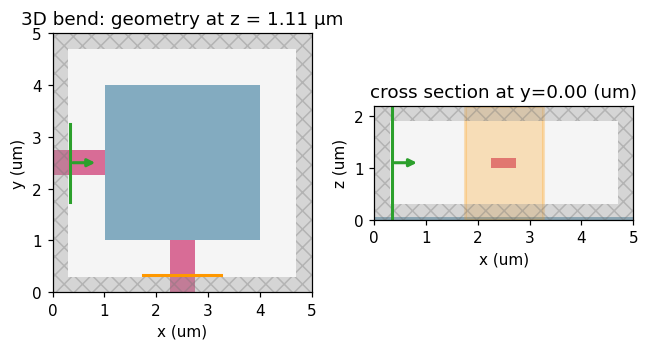

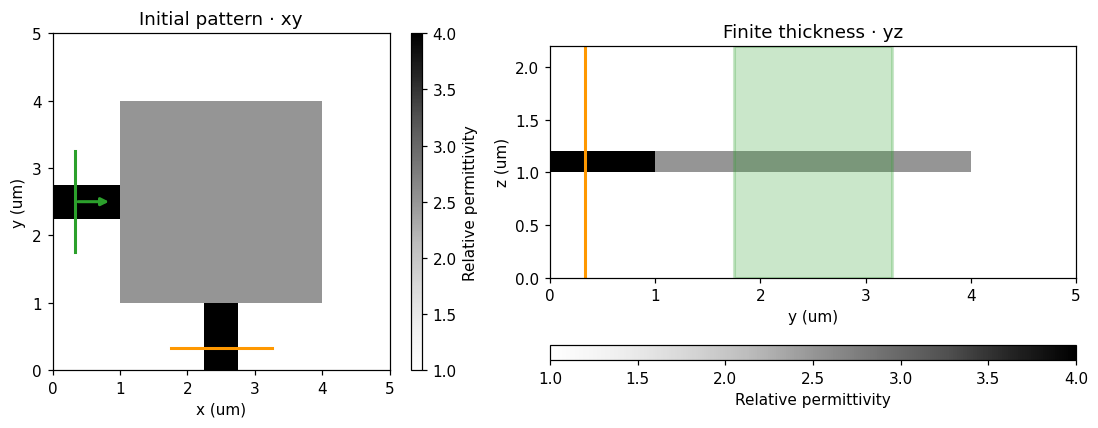

In [3]:
fig, ax = initial_simulation.plot(z=1.11*um, figsize=(6,5))
ax[0].set_title("3D bend: geometry at z = 1.11 µm")
plt.show()
fig, axes = plt.subplots(1,2,figsize=(11,4))
initial_simulation.plot_eps(z=1.11*um, ax=axes[0], vmin=1, vmax=4, title="Initial pattern · xy")
initial_simulation.plot_eps(x=2.51*um, ax=axes[1], vmin=1, vmax=4, title="Finite thickness · yz")
plt.show()

## Checks
### Compare full autodiff, spectral adjoint, and finite differences
Use the same reference geometry at 100 nm. This validates the vector derivative on an affordable fixture; it does not establish mesh convergence. A deterministic perturbation makes the comparison exercise nonuniform materials.

In [4]:
check_ad = make_bend(resolution=100e-9, gradient_backend="autodiff")
check_adj = check_ad.updated_copy(gradient_backend="adjoint")
check_params = check_ad.design_region.initial_parameters + np.random.default_rng(7).uniform(
    -.02, .02, check_ad.design_region.params_shape)
fun_ad = check_ad.make_objective_fn(post_process)
va, ga = jax.value_and_grad(fun_ad)(check_params)
vb, gb = jax.value_and_grad(check_adj.make_objective_fn(post_process))(check_params)
gradient_error = float(np.linalg.norm(ga-gb)/np.linalg.norm(ga))
direction = np.asarray(ga)/np.linalg.norm(ga)
h = .003
finite_difference = float((fun_ad(check_params+h*direction)-fun_ad(check_params-h*direction))/(2*h))
ad_directional = float(np.sum(ga*direction))
print(f"Adjoint/autodiff relative gradient difference: {100*gradient_error:.5f}%")
print(f"Directional derivative: autodiff={ad_directional:.7g}, finite difference={finite_difference:.7g}")
assert gradient_error < 3e-3
np.testing.assert_allclose(finite_difference, ad_directional, rtol=.01, atol=1e-7)
check_diagnostics = check_adj.gradient_diagnostics
print(check_diagnostics)
del check_ad, check_adj, fun_ad, ga, gb
jax.clear_caches(); gc.collect()

Adjoint/autodiff relative gradient difference: 0.00025%
Directional derivative: autodiff=0.02901014, finite difference=0.02900759
{'terminal_field_ratio': 2.8914112704114814e-07, 'decay_tolerance': 0.0001, 'adjoint_solves': 1, 'source_grouping': 'frequency', 'adjoint_terminal_field_ratios': (7.576031748612877e-07,), 'adjoint_timesteps': (2099,), 'stored_design_dft_values': 7502}


687

## Steps
### Initial fields
As in the reference, show permittivity, electric-field squared magnitude, and the real Ex/Ey components. All spatial plots use BeamZ utilities.

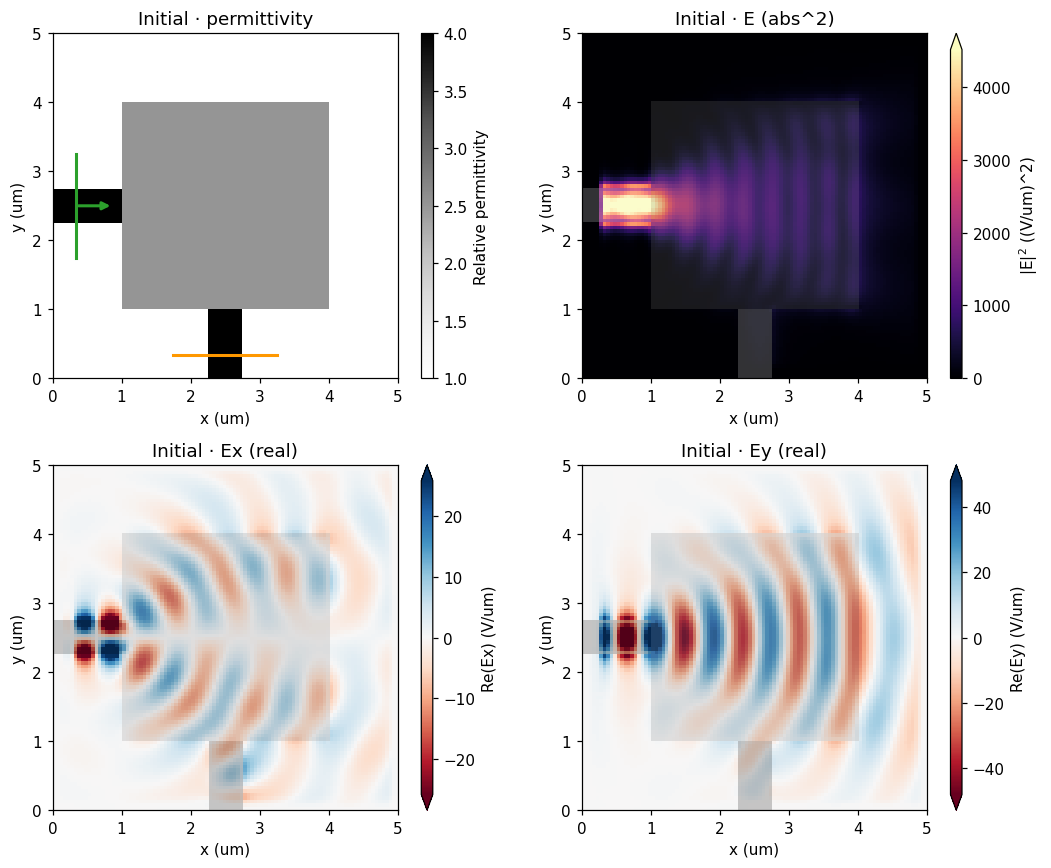

Initial source-normalized target-mode power: 0.004988


In [5]:
field_monitor = FieldMonitor(center=(2.5*um,2.5*um,1.1*um), size=(5*um,5*um,0),
                             freqs=[frequency], fields=("Ex","Ey","Ez"), name="field")
def field_run(simulation):
    return simulation.updated_copy(monitors=[*simulation.monitors,field_monitor]).run(
        backend="jax", performance=False)

def plot_reference_fields(simulation, data, title):
    fig, axes = plt.subplots(2,2,figsize=(11,8))
    simulation.plot_eps(z=1.11*um, ax=axes[0,0], vmin=1, vmax=4, title=title+" · permittivity")
    for axis, component, value in [(axes[0,1],"E","abs^2"),(axes[1,0],"Ex","real"),(axes[1,1],"Ey","real")]:
        data.plot_field("field", field_name=component, val=value, frequency=frequency, ax=axis)
        axis.set_title(f"{title} · {component} ({value})")
    fig.tight_layout()
    return fig

initial_fields = field_run(initial_simulation)
initial_power = float(np.sum(abs(initial_fields.mode("mode").amps.sel(direction="-",mode_index=0).values)**2))
plot_reference_fields(initial_simulation, initial_fields, "Initial")
plt.show()
print(f"Initial source-normalized target-mode power: {initial_power:.6f}")

### Optimize with the high-level workflow
Switch `gradient_backend` in `make_bend` to use full autodiff. The spectral adjoint retains only design-region electric DFTs, independent of timestep count. Every iteration checks forward and adjoint decay; an unconverged pulse raises an error.

In [6]:
optimizer = bi.AdamOptimizer(design=design, learning_rate=.1, objective_id="3d-bend-target-mode-power-v1")
started = time.perf_counter()
def progress(result):
    print(f"Step {result.completed_steps:2d}: power={result.history[-1].post_process_val:.6f}, "
          f"penalty={result.history[-1].penalty:.6f}, elapsed={time.perf_counter()-started:.1f} s", flush=True)
result = optimizer.run(post_process, steps=num_steps,
    checkpoint=artifacts/"history.npz", checkpoint_every=5, callback=progress)
optimization_seconds = time.perf_counter()-started
restored = optimizer.load_result(artifacts/"history.npz", post_process)
np.testing.assert_array_equal(restored.params[-1], result.params[-1])
print("Checkpoint restored exactly.")
np.testing.assert_allclose(result.history[0].post_process_val, initial_power, rtol=5e-5, atol=1e-7)
print(design.gradient_diagnostics)

Step  1: power=0.004988, penalty=1.000000, elapsed=137.8 s


Step  2: power=0.226613, penalty=1.000000, elapsed=285.4 s


Step  3: power=0.358087, penalty=1.000000, elapsed=458.9 s


Step  4: power=0.484459, penalty=0.999881, elapsed=608.5 s


Step  5: power=0.569794, penalty=0.977240, elapsed=731.7 s


...

Step  7: power=0.660765, penalty=0.881544, elapsed=1044.4 s


Step  8: power=0.692655, penalty=0.849435, elapsed=1210.3 s


Step  9: power=0.705467, penalty=0.809070, elapsed=1403.9 s


Step 10: power=0.724102, penalty=0.764608, elapsed=1624.2 s


Checkpoint restored exactly.
{'terminal_field_ratio': 2.8009787911287276e-07, 'decay_tolerance': 0.0001, 'adjoint_solves': 1, 'source_grouping': 'frequency', 'adjoint_terminal_field_ratios': (1.3787675925414078e-06,), 'adjoint_timesteps': (4197,), 'stored_design_dft_values': 51484}


### Optimization history and final fields
History values are evaluated before each Adam update. Final performance below is evaluated after the last update. The penalized objective and optical power are reported separately.

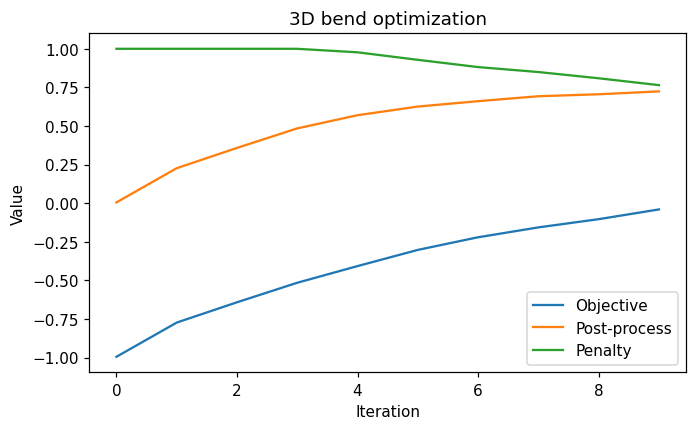

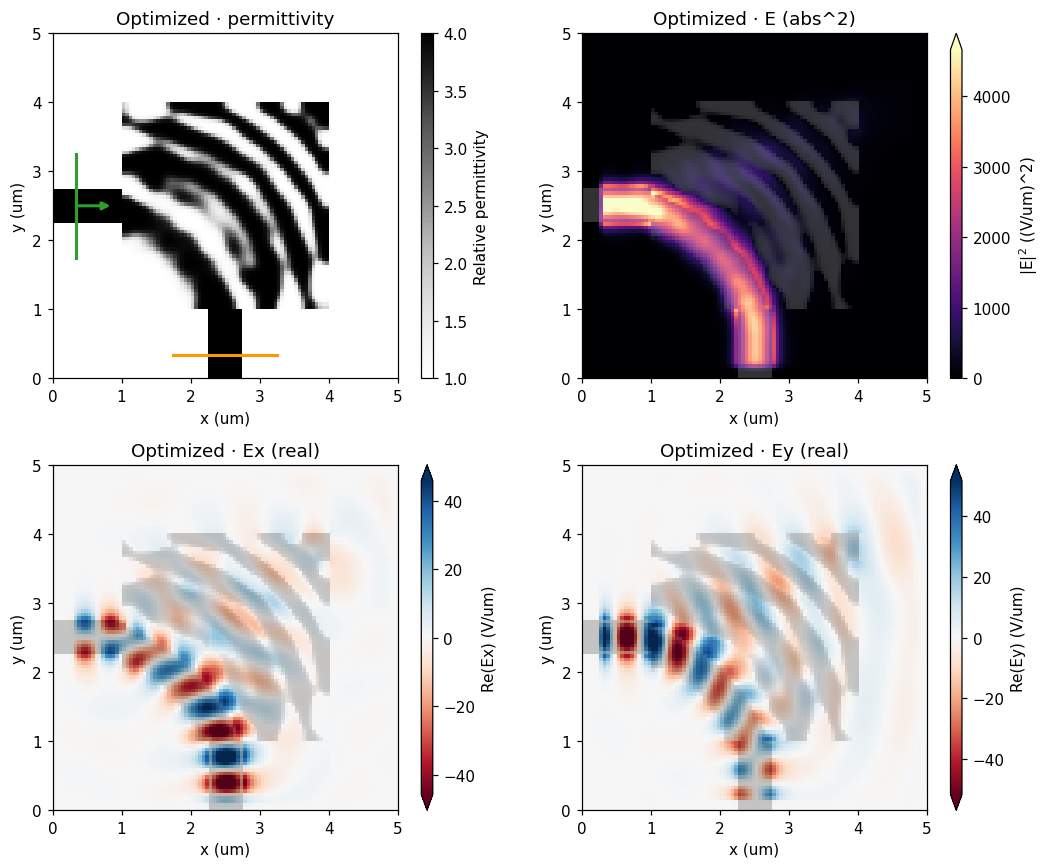

Target-mode power: 0.004988 → 0.734932


In [7]:
fig, ax = plt.subplots(figsize=(7,4))
result.plot_optimization(ax=ax)
ax.set_title("3D bend optimization")
plt.show()
final_simulation = result.to_simulation()
final_fields = field_run(final_simulation)
final_power = float(np.sum(abs(final_fields.mode("mode").amps.sel(direction="-",mode_index=0).values)**2))
plot_reference_fields(final_simulation, final_fields, "Optimized")
plt.show()
assert final_power > initial_power
print(f"Target-mode power: {initial_power:.6f} → {final_power:.6f}")

### Transmission spectrum and longer-run verification
The reference plots transmission versus wavelength. Here an ordinary 800 fs FDTD run evaluates the final continuous design over 0.9–1.1 µm. This plot is source-normalized modal power; it is not normalized by a separately measured incident port. No values are clipped to the physical interval.

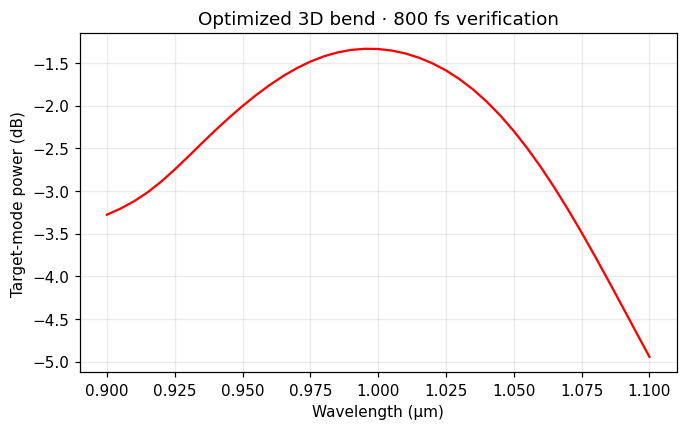

400 → 800 fs: 0.734932 → 0.734932; change=0.0000 percentage points


In [8]:
wavelengths = np.linspace(.9,1.1,41)*um
spectral_monitor = final_simulation.monitors[0].updated_copy(freqs=LIGHT_SPEED/wavelengths)
verification = final_simulation.updated_copy(run_time=800e-15,monitors=[spectral_monitor]).run(
    backend="jax", performance=False)
power_spectrum = np.abs(verification.mode("mode").amps.sel(direction="-",mode_index=0).values)**2
power_spectrum = np.asarray(power_spectrum).reshape(-1)
long_power = float(power_spectrum[len(wavelengths)//2])
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(wavelengths/um,10*np.log10(np.maximum(power_spectrum,1e-15)),color="red")
ax.set(xlabel="Wavelength (µm)",ylabel="Target-mode power (dB)",title="Optimized 3D bend · 800 fs verification")
ax.grid(alpha=.25)
plt.show()
print(f"400 → 800 fs: {final_power:.6f} → {long_power:.6f}; change={100*(long_power-final_power):.4f} percentage points")

### Export and independently rerasterize the binary geometry
`export_design()` creates ordinary polygons with the correct extrusion height. Compare the same exported geometry at 50 and 40 nm; thresholding and mesh changes are distinct effects. Five cells resolve the thickness at 40 nm, so a smaller change is not proof of full mesh convergence.

Binary export at 50 nm: 0.714983


Binary export at 40 nm: 0.745034


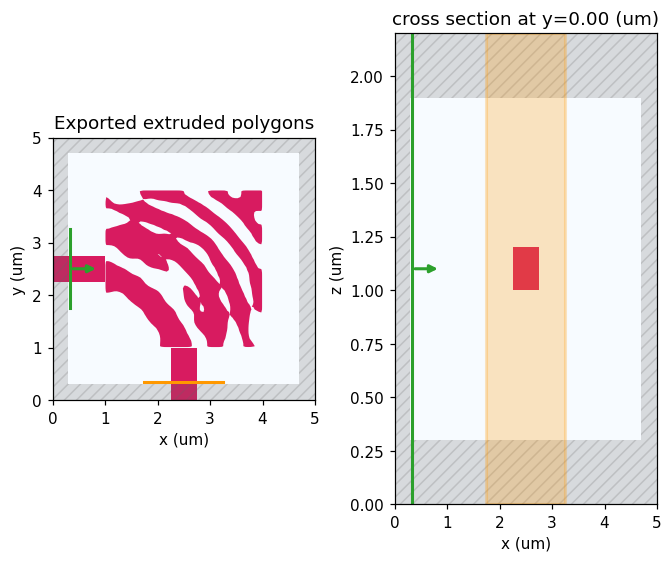

In [9]:
binary_geometry = design.export_design(result.params[-1])
binary_powers = {}
for resolution in (50e-9,40e-9):
    binary_simulation = design.simulation.updated_copy(design=binary_geometry,
        resolution=resolution,run_time=800e-15)
    binary_data = binary_simulation.run(backend="jax",performance=False)
    binary_powers[float(resolution)] = float(np.sum(abs(binary_data.mode("mode").amps.sel(
        direction="-",mode_index=0).values)**2))
    print(f"Binary export at {resolution/1e-9:.0f} nm: {binary_powers[float(resolution)]:.6f}")
fig, ax = binary_simulation.plot(z=1.11*um,figsize=(6,5))
ax[0].set_title("Exported extruded polygons")
plt.show()

## Results
The summary is calculated from this execution. The notebook demonstrates the feature and reference workflow; it does not claim fabrication readiness or Tidy3D numerical parity.

In [10]:
metrics = dict(initial_power=initial_power,final_power=final_power,long_run_power=long_power,
               gradient_relative_error=gradient_error,optimization_seconds=optimization_seconds,
               binary_power_50nm=binary_powers[50e-9],binary_power_40nm=binary_powers[40e-9],
               mesh_nm=dx/1e-9,num_steps=num_steps,run_time_fs=run_time/1e-15)
(artifacts/"metrics.json").write_text(json.dumps(metrics,indent=2)+"\n")
np.savez_compressed(artifacts/"spectra.npz",wavelengths=wavelengths,power=power_spectrum)
display(Markdown(f"**Full 3D result:** source-normalized target-mode power improved from "
    f"**{initial_power:.4f} to {final_power:.4f}** after {num_steps} updates at {dx/1e-9:g} nm. "
    f"The 800 fs value is **{long_power:.4f}**. On the coarse gradient fixture, the backends "
    f"differ by **{100*gradient_error:.5f}%**. The exported binary geometry gives "
    f"**{binary_powers[50e-9]:.4f} / {binary_powers[40e-9]:.4f}** at 50 / 40 nm."))

**Full 3D result:** source-normalized target-mode power improved from **0.0050 to 0.7349** after 10 updates at 50 nm. The 800 fs value is **0.7349**. On the coarse gradient fixture, the backends differ by **0.00025%**. The exported binary geometry gives **0.7150 / 0.7450** at 50 / 40 nm.

## Next steps
The same API now supports extruded patterns in vector 3D with both gradient routes, native plots, checkpoint restoration, and polygon export. General volumetric filter/penalty workflows, shape derivatives, multiple independent excitations, and lossy/dispersive gradients remain separate milestones.

Reference: Flexcompute, *Topology optimization of a waveguide bend*, `Autograd18TopologyBend.ipynb`, accessed 2026-09-21. No Tidy3D cloud simulation was run.

## Export the binary layout to GDS

Install the optional layout dependency with `pip install "beamz[gds]"`. Export the final projected density at threshold 0.5 together with the fixed input/output waveguides. The low-index background and the design-region clearing polygons are excluded, leaving only the core mask on layer **0/0**. Coordinates are converted from metres to GDS micrometres by `export_gds`; polygon holes are preserved.

Files go to `results/topology_examples/gds` by default. Set `BEAMZ_GDS_DIR` to choose another destination. GDS stores the planar mask, not a layer thickness or a substrate. These layouts are example simulation results, not fabrication-qualified masks.

The modeled core is 200 nm thick; retain that thickness when extruding this mask for 3D visualization.


In [ ]:
import os
from uuid import uuid4
from beamz.design import export_gds

# Unique cell names allow re-running this cell in the same gdsfactory session.

gds_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
gds_dir = Path(os.environ.get("BEAMZ_GDS_DIR", gds_root / "results/topology_examples/gds")).expanduser()
gds_dir.mkdir(parents=True, exist_ok=True)

binary_layout = result.export_design(threshold=0.5)
# Clearing polygons represent cladding, not material to pattern.
core_layout = Design(
    width=binary_layout.width, height=binary_layout.height, depth=binary_layout.depth,
    background=binary_layout.background,
    structures=[s for s in binary_layout.structures
                if s.material.permittivity > binary_layout.background.permittivity],
)
gds_path = export_gds(core_layout, gds_dir / "tidy3d_topology_bend_3d.gds",
                      cell_name=f"topology_bend_3d_{uuid4().hex[:8]}")
print(f"GDS core mask (layer 0/0): {gds_path.resolve()}")
